# Health InsurTech — Analyse & Modélisation
**Objectif :** Prédire les frais médicaux annuels à partir de variables de santé anonymisées.

Étapes : Chargement → Nettoyage RGPD → EDA → Modélisation → Comparaison des modèles → Sauvegarde

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Imports OK')

Imports OK


## 2. Chargement du dataset brut

In [3]:
df_raw = pd.read_csv('../data/insurance_data.csv')  # dataset original avec PII
print(f'Shape : {df_raw.shape}')
df_raw.head(3)

Shape : (1338, 22)


,id_client,nom,prenom,date_naissance,sexe,email,telephone,numero_secu_sociale,ville,code_postal,...,sex,bmi,children,smoker,region,charges,mutuelle_complementaire,adresse_ip,consentement_rgpd,date_inscription
0,CLI00001,Laurent,Cécile,04/11/2007,F,cecile.laurent@hotmail.fr,643842498,207116416078825,Bayonne,64100,...,female,27.90,0,yes,southwest,16884.9240,Maaf Santé,245.164.69.170,Oui,19/11/2018
1,CLI00002,Moulin,Guillaume,24/01/2008,M,guillaume_moulin46@gmail.com,682992299,108010691680375,Nice,6000,...,male,33.77,1,no,southeast,1725.5523,Groupama,57.173.29.88,Oui,12/11/2021
2,CLI00003,Joly,Frédéric,08/05/1998,M,fredericjoly@orange.fr,790010943,198050622504036,Antibes,6600,...,male,33.00,3,no,southeast,4449.4620,Aucune,227.165.135.149,Oui,19/06/2024


In [4]:
print('Colonnes :', df_raw.columns.tolist())
print('\nTypes :')
print(df_raw.dtypes)
print('\nValeurs manquantes :')
print(df_raw.isnull().sum())

Colonnes : ['id_client', 'nom', 'prenom', 'date_naissance', 'sexe', 'email', 'telephone', 'numero_secu_sociale', 'ville', 'code_postal', 'region_fr', 'age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'mutuelle_complementaire', 'adresse_ip', 'consentement_rgpd', 'date_inscription']

Types :
id_client                   object
nom                         object
prenom                      object
date_naissance              object
sexe                        object
email                       object
telephone                    int64
numero_secu_sociale          int64
ville                       object
code_postal                  int64
region_fr                   object
age                          int64
sex                         object
bmi                        float64
children                     int64
smoker                      object
region                      object
charges                    float64
mutuelle_complementaire     object
adresse_ip                  ob

## 3. Nettoyage RGPD — Suppression des PII

On supprime toutes les colonnes à caractère personnel (Art. 5 RGPD — minimisation des données).

In [5]:
PII_COLS = [
    'id_client', 'nom', 'prenom', 'date_naissance', 'email',
    'telephone', 'numero_secu_sociale', 'ville', 'code_postal',
    'adresse_ip', 'consentement_rgpd', 'date_inscription', 'mutuelle_complementaire'
]

df = df_raw.drop(columns=PII_COLS, errors='ignore').copy()
print(f'Colonnes conservées : {df.columns.tolist()}')
print(f'Shape après nettoyage : {df.shape}')
df.head(3)

Colonnes conservées : ['sexe', 'region_fr', 'age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Shape après nettoyage : (1338, 9)


,sexe,region_fr,age,sex,bmi,children,smoker,region,charges
0,F,Nouvelle-Aquitaine,19,female,27.90,0,yes,southwest,16884.9240
1,M,Provence-Alpes-Côte d'Azur,18,male,33.77,1,no,southeast,1725.5523
2,M,Provence-Alpes-Côte d'Azur,28,male,33.00,3,no,southeast,4449.4620


In [26]:
#telechargement du dataset nettoyé pour utilisation dans l'application
df.to_csv('../data/insurance_clean.csv', index=False)
print('Dataset nettoyé sauvegardé : ../data/insurance_clean.csv')

Dataset nettoyé sauvegardé : ../data/insurance_clean.csv


## 4. Analyse Exploratoire (EDA)

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


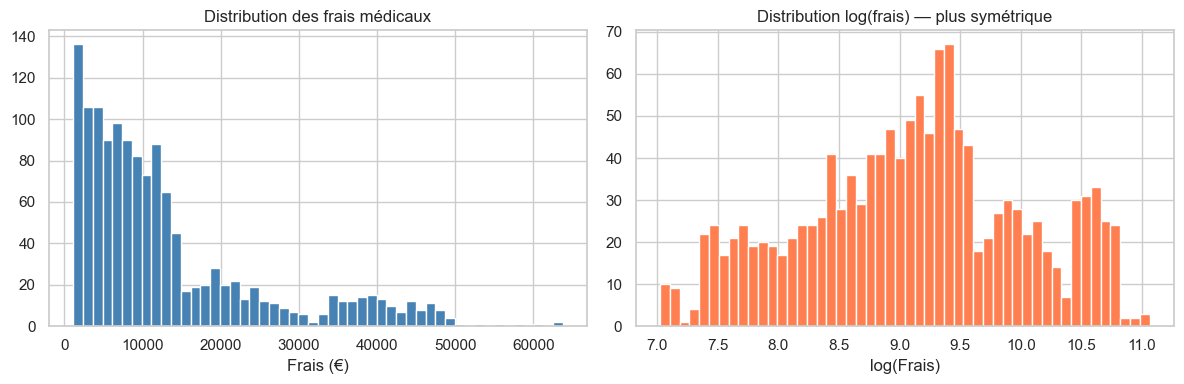

Skewness : 1.52 (distribution fortement asymétrique à droite)


In [8]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['charges'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des frais médicaux')
axes[0].set_xlabel('Frais (€)')

axes[1].hist(np.log(df['charges']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution log(frais) — plus symétrique')
axes[1].set_xlabel('log(Frais)')

plt.tight_layout()
plt.show()
print(f'Skewness : {df.charges.skew():.2f} (distribution fortement asymétrique à droite)')

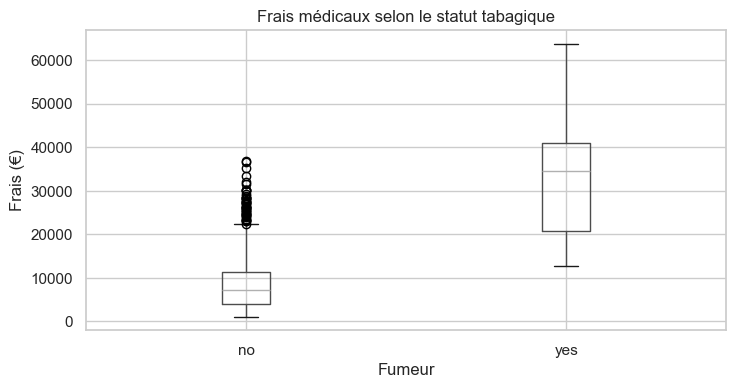

smoker
no      8434.0
yes    32050.0
Name: charges, dtype: float64


In [9]:
# Frais selon le statut fumeur
fig, ax = plt.subplots(figsize=(8, 4))
df.boxplot(column='charges', by='smoker', ax=ax)
ax.set_title('Frais médicaux selon le statut tabagique')
ax.set_xlabel('Fumeur')
ax.set_ylabel('Frais (€)')
plt.suptitle('')
plt.show()

print(df.groupby('smoker')['charges'].mean().round(0))

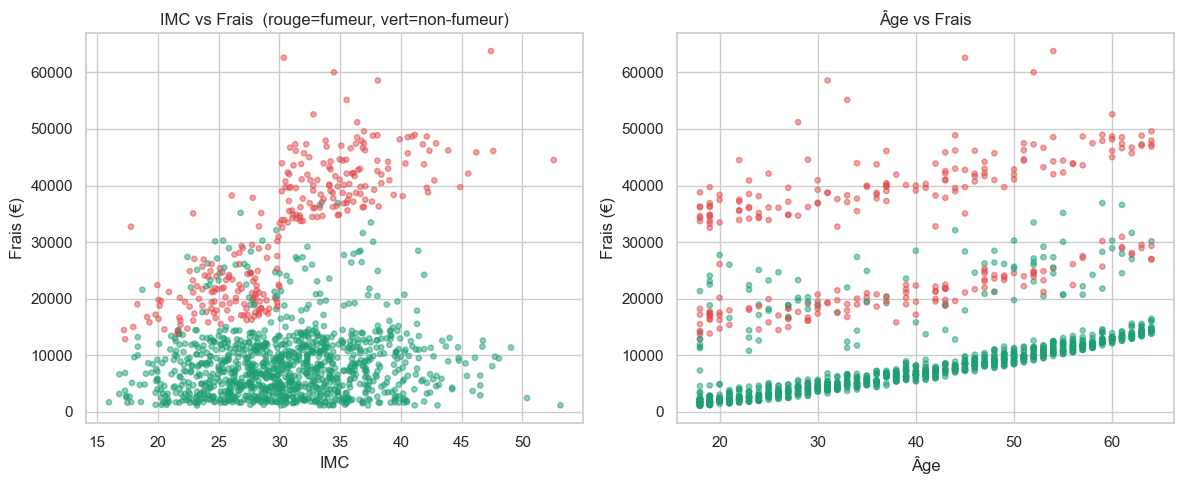

In [10]:
# Corrélation IMC / Âge / Charges
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = df['smoker'].map({'yes': '#E24B4A', 'no': '#1D9E75'})

axes[0].scatter(df['bmi'], df['charges'], c=colors, alpha=0.5, s=15)
axes[0].set_xlabel('IMC')
axes[0].set_ylabel('Frais (€)')
axes[0].set_title('IMC vs Frais  (rouge=fumeur, vert=non-fumeur)')

axes[1].scatter(df['age'], df['charges'], c=colors, alpha=0.5, s=15)
axes[1].set_xlabel('Âge')
axes[1].set_ylabel('Frais (€)')
axes[1].set_title('Âge vs Frais')

plt.tight_layout()
plt.show()

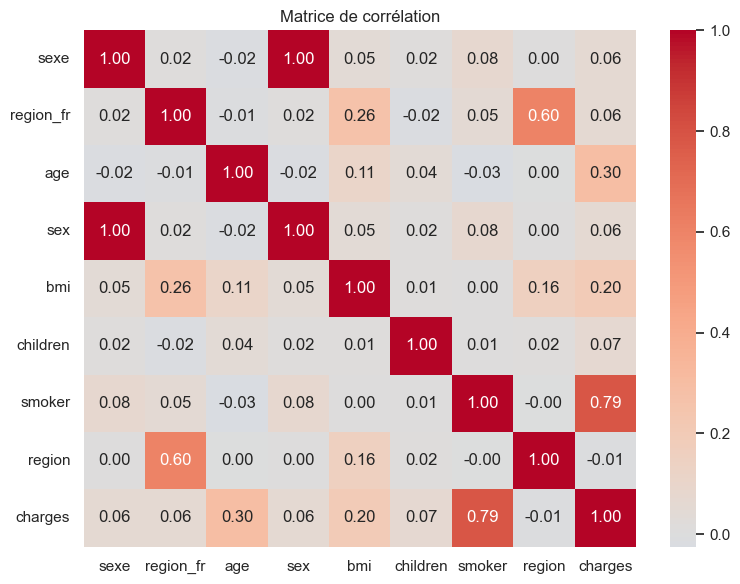


Corrélation avec charges :
charges      1.000000
smoker       0.787251
age          0.299008
bmi          0.198341
children     0.067998
sexe         0.057292
sex          0.057292
region_fr    0.056993
region      -0.006208
Name: charges, dtype: float64


In [13]:
# Matrice de corrélation
df_enc = df.copy()

# Encoder TOUTES les colonnes texte
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

plt.figure(figsize=(8, 6))
sns.heatmap(df_enc.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

print('\nCorrélation avec charges :')
print(df_enc.corr(numeric_only=True)['charges'].sort_values(ascending=False))

## 5. Préparation des données pour le modèle

In [14]:
X = df_enc[['age', 'sex', 'bmi', 'children', 'smoker']]
y = df_enc['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes')

Train : 1070 lignes | Test : 268 lignes


## 6. Modèle 1 — Régression Linéaire

Modèle interprétable : chaque coefficient indique l'impact direct d'une variable sur les frais.

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr  = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f'R²   : {r2_lr:.4f}')
print(f'MAE  : {mae_lr:,.0f} €')
print(f'RMSE : {rmse_lr:,.0f} €')

R²   : 0.7811
MAE  : 4,213 €
RMSE : 5,829 €


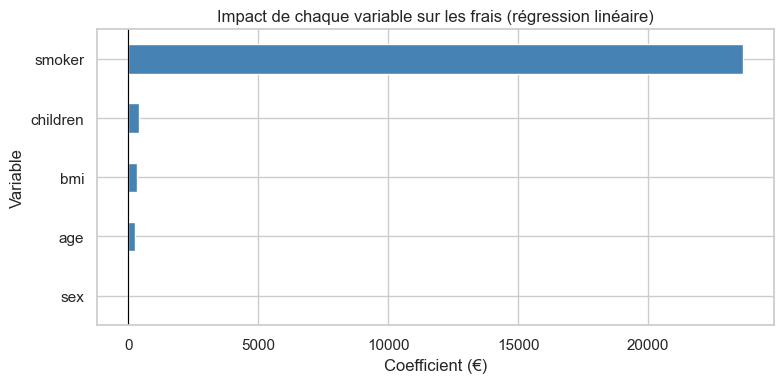

Variable  Coefficient (€)
     sex             -8.0
     age            257.1
     bmi            327.5
children            427.3
  smoker          23653.9


In [16]:
# Interprétation des coefficients
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient (€)': lr.coef_.round(1)
}).sort_values('Coefficient (€)', ascending=True)

coef_df.plot(kind='barh', x='Variable', y='Coefficient (€)', figsize=(8, 4),
             color='steelblue', legend=False)
plt.title('Impact de chaque variable sur les frais (régression linéaire)')
plt.xlabel('Coefficient (€)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print(coef_df.to_string(index=False))

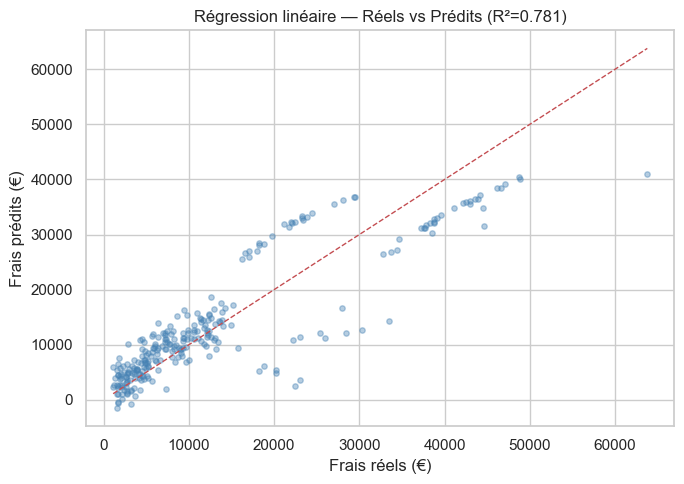

In [17]:
# Valeurs prédites vs réelles
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.4, s=15, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
plt.xlabel('Frais réels (€)')
plt.ylabel('Frais prédits (€)')
plt.title(f'Régression linéaire — Réels vs Prédits (R²={r2_lr:.3f})')
plt.tight_layout()
plt.show()

In [18]:
# Cross-validation
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='r2')
print(f'CV R² (5 folds) : {cv_scores.round(3)}')
print(f'Moyenne : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

CV R² (5 folds) : [0.761 0.709 0.776 0.731 0.757]
Moyenne : 0.747 ± 0.024


## 7. Modèle 2 — Arbre de Décision

Autre modèle interprétable : on peut visualiser les règles de décision.

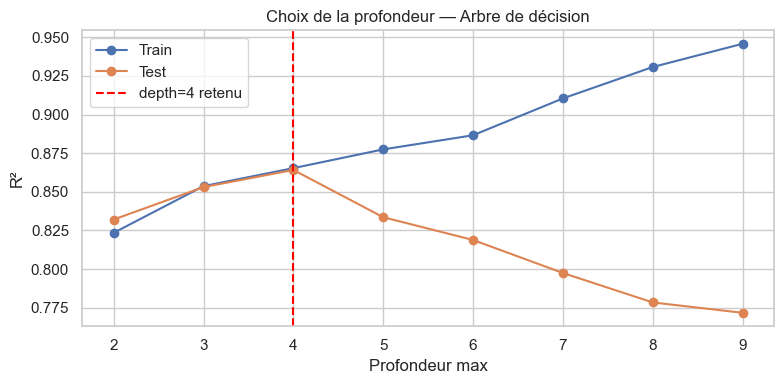

Profondeur 4 : bon compromis biais/variance


In [19]:
# Test de différentes profondeurs
depths = range(2, 10)
r2_train, r2_test_ = [], []

for d in depths:
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    r2_train.append(r2_score(y_train, dt.predict(X_train)))
    r2_test_.append(r2_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(depths, r2_train, label='Train', marker='o')
plt.plot(depths, r2_test_, label='Test', marker='o')
plt.axvline(4, color='red', linestyle='--', label='depth=4 retenu')
plt.xlabel('Profondeur max')
plt.ylabel('R²')
plt.title('Choix de la profondeur — Arbre de décision')
plt.legend()
plt.tight_layout()
plt.show()
print('Profondeur 4 : bon compromis biais/variance')

In [20]:
dt = DecisionTreeRegressor(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

r2_dt  = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print(f'R²   : {r2_dt:.4f}')
print(f'MAE  : {mae_dt:,.0f} €')
print(f'RMSE : {rmse_dt:,.0f} €')

R²   : 0.8641
MAE  : 2,698 €
RMSE : 4,593 €


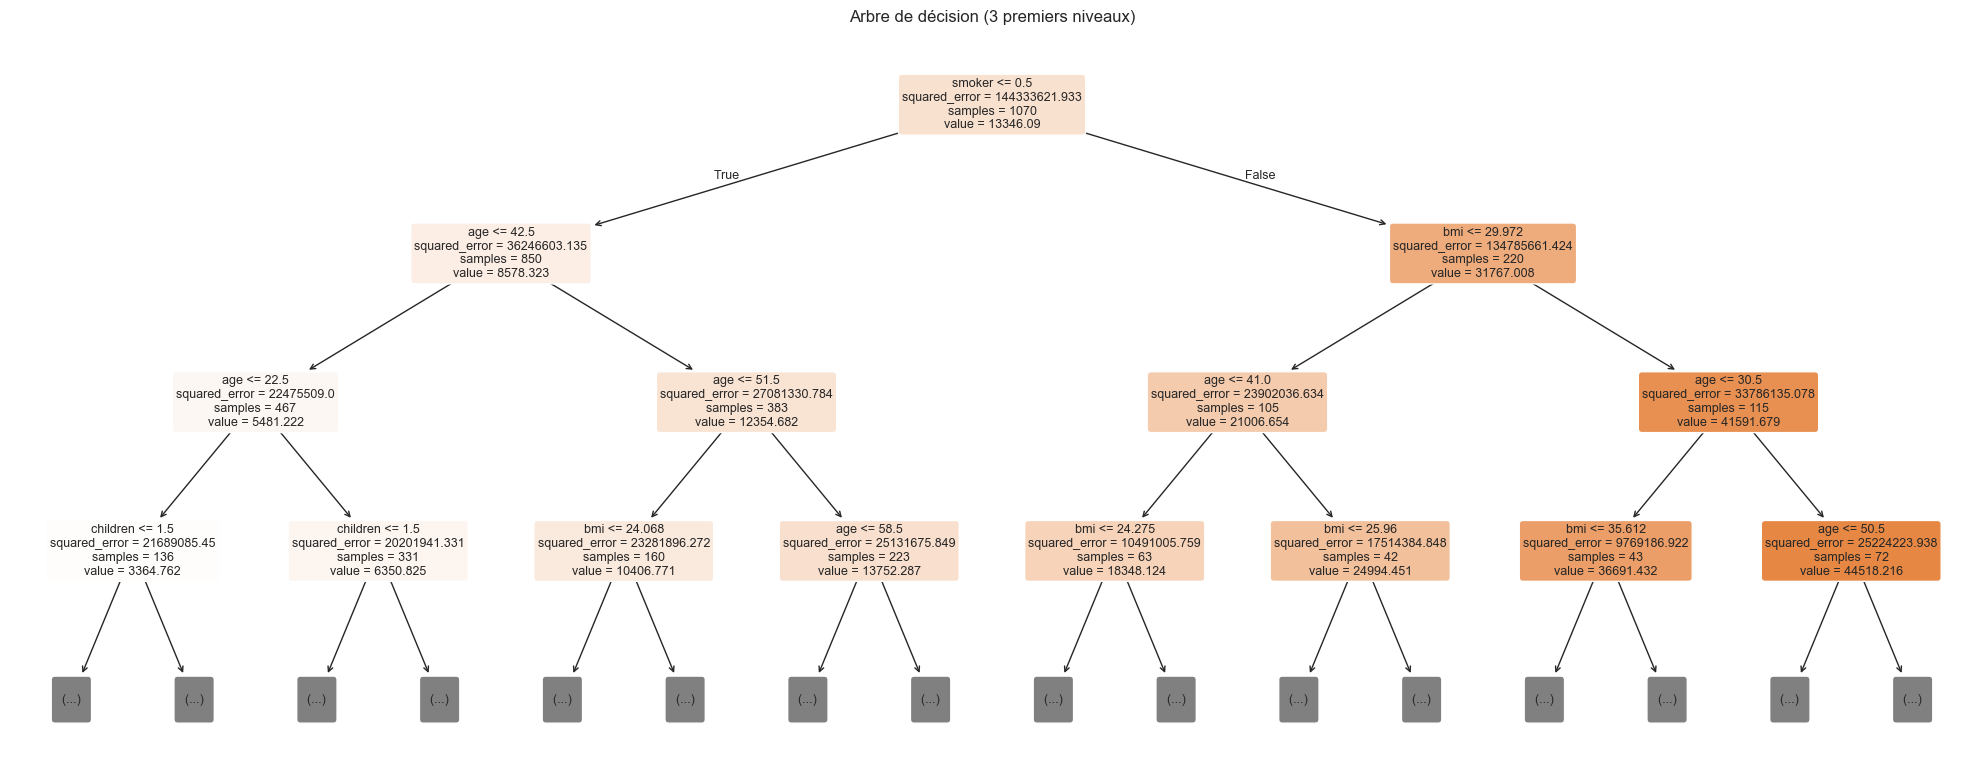

In [21]:
# Visualisation de l'arbre
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=X.columns, filled=True, rounded=True,
          max_depth=3, ax=ax, fontsize=9)
plt.title('Arbre de décision (3 premiers niveaux)')
plt.tight_layout()
plt.show()

## 8. Comparaison des modèles — Quel est le meilleur R² ?

In [22]:
results = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'Arbre de Décision (depth=4)'],
    'R²': [r2_lr, r2_dt],
    'MAE (€)': [mae_lr, mae_dt],
    'RMSE (€)': [rmse_lr, rmse_dt],
    'Interprétable': ['Oui (coefficients)', 'Oui (règles visuelles)']
})
results = results.round({'R²': 3, 'MAE (€)': 0, 'RMSE (€)': 0})
print(results.to_string(index=False))

                     Modèle    R²  MAE (€)  RMSE (€)          Interprétable
        Régression Linéaire 0.781   4213.0    5829.0     Oui (coefficients)
Arbre de Décision (depth=4) 0.864   2698.0    4593.0 Oui (règles visuelles)


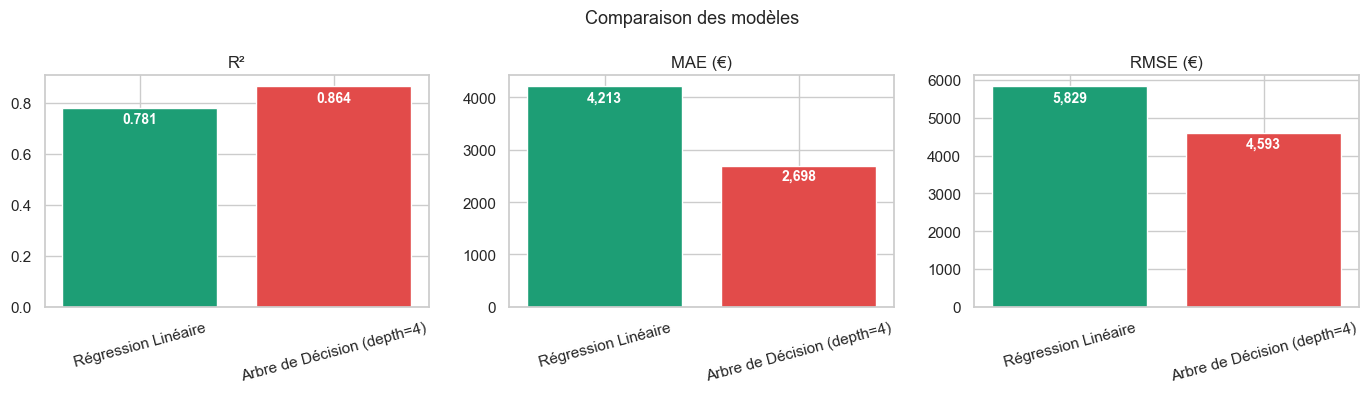


→ L'Arbre de Décision obtient le meilleur R² (0.864 vs 0.781).
→ La Régression Linéaire reste préférable pour l'app : coefficients directement interprétables par l'utilisateur.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = ['R²', 'MAE (€)', 'RMSE (€)']
colors = ['#1D9E75', '#E24B4A']

for i, metric in enumerate(metrics):
    vals = results[metric].values
    axes[i].bar(results['Modèle'], vals, color=colors)
    axes[i].set_title(metric)
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(vals):
        axes[i].text(j, v * 0.98, f'{v:,.0f}' if metric != 'R²' else f'{v:.3f}',
                     ha='center', va='top', fontsize=10, color='white', fontweight='bold')

plt.suptitle('Comparaison des modèles', fontsize=13)
plt.tight_layout()
plt.show()

print()
print('→ L\'Arbre de Décision obtient le meilleur R² (0.864 vs 0.781).')
print('→ La Régression Linéaire reste préférable pour l\'app : coefficients directement interprétables par l\'utilisateur.')

## 9. Analyse des biais — Fumeurs et régions

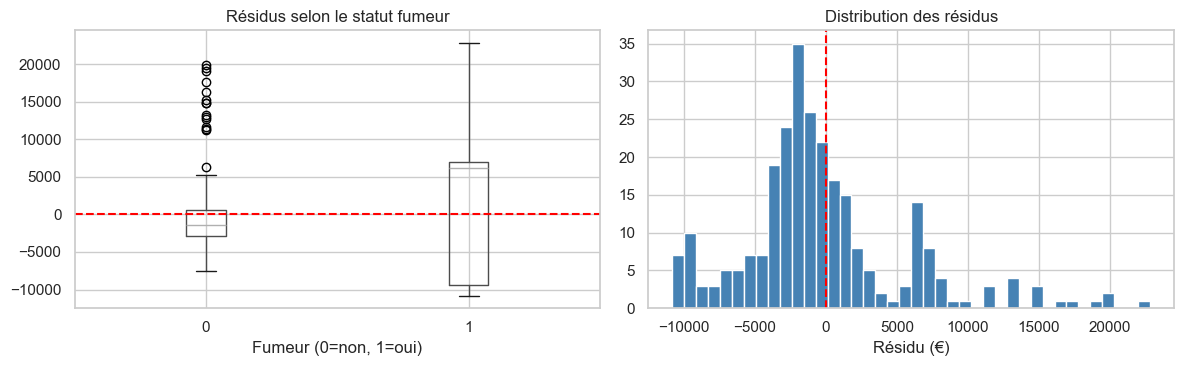

Résidus moyens par groupe fumeur :
smoker
0   -390.0
1    405.0
Name: residus, dtype: float64


In [24]:
# Résidus par groupe
df_test = X_test.copy()
df_test['charges_reel'] = y_test.values
df_test['charges_predit'] = y_pred_lr
df_test['residus'] = df_test['charges_reel'] - df_test['charges_predit']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Résidus fumeurs vs non-fumeurs
df_test.boxplot(column='residus', by='smoker', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Résidus selon le statut fumeur')
axes[0].set_xlabel('Fumeur (0=non, 1=oui)')
plt.suptitle('')

# Distribution des résidus
axes[1].hist(df_test['residus'], bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribution des résidus')
axes[1].set_xlabel('Résidu (€)')

plt.tight_layout()
plt.show()

print('Résidus moyens par groupe fumeur :')
print(df_test.groupby('smoker')['residus'].mean().round(0))

## 10. Sauvegarde des modèles

In [25]:
import os
os.makedirs('../model', exist_ok=True)

with open('../model/model_lr.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('../model/model_dt.pkl', 'wb') as f:
    pickle.dump(dt, f)

print('Modèles sauvegardés :')
print('  → model/model_lr.pkl  (Régression Linéaire, R²=0.781) — utilisé dans l\'app')
print('  → model/model_dt.pkl  (Arbre de Décision,  R²=0.864)')

Modèles sauvegardés :
  → model/model_lr.pkl  (Régression Linéaire, R²=0.781) — utilisé dans l'app
  → model/model_dt.pkl  (Arbre de Décision,  R²=0.864)


## Conclusion

| Modèle | R² | MAE | Interprétable | Choix app |
|---|---|---|---|---|
| Régression Linéaire | 0.781 | 4 214 € | ✅ Coefficients | ✅ **Retenu** |
| Arbre de Décision | 0.864 | — | ✅ Règles visuelles | — |

La régression linéaire est retenue dans l'application Streamlit car ses coefficients sont directement affichables et compréhensibles par l'utilisateur final, conformément aux exigences d'interprétabilité du projet.